# Spherical Collisions
Development notebook for testing different methods for the spherical portion of the Laplacian

In [1]:
# %% Import JAX and enable 64-bit precision
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
# %% Import other libraries
import equinox as eqx
import interpax
import diffrax
import optimistix as optx

import numpy as np
import jax.numpy as jnp
import jax.tree_util as jtu
from dataclasses import dataclass
from functools import partial, reduce
import numpy as np
from collections import namedtuple
from typing import NamedTuple
import matplotlib.pyplot as plt
import os

from netCDF4 import Dataset

from jaxtyping import ArrayLike, Real, Array
from tqdm.notebook import tqdm

In [3]:
jnp.cross(jnp.eye(3), jnp.array([1.0, 2.0, 3.0]))

Array([[ 0., -3.,  2.],
       [ 3.,  0., -1.],
       [-2.,  1.,  0.]], dtype=float64)

In [39]:
# %% SDE via generators of so(3)
def vf_so3(t, y, args):
    return jnp.cross(jnp.eye(3), y)

t0 = 0.0
dt0 = 1e-3
max_steps = 4096
t1 = dt0 * max_steps

saveat = diffrax.SaveAt(t0=True, t1=True, steps=True)
stepsize_controller = diffrax.ConstantStepSize()
solver = diffrax.Heun()

control = diffrax.VirtualBrownianTree(t0=t0, t1=t1, tol=dt0/2, shape=(3,), key=jax.random.PRNGKey(0))
term = diffrax.ControlTerm(vf_so3, control)

y0 = jnp.array([1.0, 0.0, 0.0])

sol = diffrax.diffeqsolve(
    term, solver,
    t0=t0, t1=t1, dt0=dt0,
    y0=y0,
    saveat=saveat,
    stepsize_controller=stepsize_controller,
    max_steps=max_steps)

Text(0, 0.5, '$v^2$')

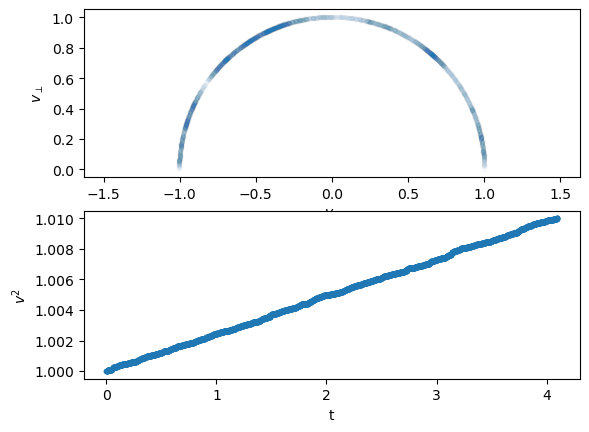

In [40]:
# %% Results of so(3) generators
plt.figure()
plt.subplot(2,1,1)
plt.scatter(sol.ys[:,0], jnp.sqrt(sol.ys[:,1]**2 + sol.ys[:,2]**2), marker='.', alpha=0.01)
plt.xlabel(R'$v_\parallel$')
plt.ylabel(R'$v_\perp$')
plt.axis('equal')

plt.subplot(2,1,2)
plt.plot(sol.ts, sol.ys[:,0]**2 + sol.ys[:,1]**2 + sol.ys[:,2]**2, marker='.')
plt.xlabel('t')
plt.ylabel('$v^2$')

In [51]:
# %% Pitch angle scattering

def vf_pitch(t, y, args):
    return jnp.array([jnp.sqrt(1-y**2)])

t0 = 0.0
dt0 = 1e-3
max_steps = 4096
t1 = dt0 * max_steps

saveat = diffrax.SaveAt(t0=True, t1=True, steps=True)
stepsize_controller = diffrax.ConstantStepSize()
solver = diffrax.Heun()

control = diffrax.VirtualBrownianTree(t0=t0, t1=t1, tol=dt0/2, shape=(1,), key=jax.random.PRNGKey(0))
term = diffrax.ControlTerm(vf_pitch, control)

y0 = jnp.array([0.5])

sol = diffrax.diffeqsolve(
    term, solver,
    t0=t0, t1=t1, dt0=dt0,
    y0=y0,
    saveat=saveat,
    stepsize_controller=stepsize_controller,
    max_steps=max_steps)

546


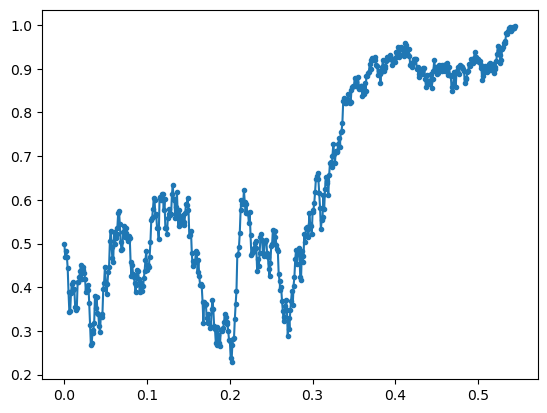

In [53]:
plt.figure()
print(np.sum(np.isfinite(sol.ys)))
plt.plot(sol.ts, sol.ys, marker='.')